In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np

# 將專案 root 加入 python path（讓 src/ 可以 import）
project_root = Path().resolve().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

print("Project root added:", project_root)
print("✓ Imports ready")

Project root added: C:\Users\USER\Desktop\2026_japan
✓ Imports ready


In [7]:
import joblib
model = joblib.load("../models/lgbm_sapporo_2.pkl")

features = [
    "weekday", "t", "x", "y", "is_weekend",
    "lag_1", "lag_7", "rolling_3", "rolling_7"
]

print("✓ Model loaded")

✓ Model loaded


In [8]:
import pandas as pd
import numpy as np


df = pd.read_parquet("../data/processed/sapporo_density.parquet")
is_unknown = (df["x"]==999) & (df["y"]==999)
df = df[~is_unknown].copy() 


# d=0 假設是 2023-01-01（你之後如果拿到真實起始日再換）
df["date"] = pd.to_datetime("2023-01-01") + pd.to_timedelta(df["d"], unit="D")
df["weekday"] = df["date"].dt.weekday
df["is_weekend"] = (df["weekday"] >= 5).astype(int)

print("Rows:", len(df))
print("d range:", df["d"].min(), df["d"].max())
print("unique days:", df["d"].nunique())

Rows: 6024088
d range: 0 74
unique days: 75


In [9]:
df = df.sort_values(["x","y","t","d"])

df["lag_1"] = df.groupby(["x","y","t"])["count"].shift(1)
df["lag_7"] = df.groupby(["x","y","t"])["count"].shift(7)

df["rolling_3"] = (
    df.groupby(["x","y","t"])["count"]
      .transform(lambda x: x.shift(1).rolling(3).mean())
)

df["rolling_7"] = (
    df.groupby(["x","y","t"])["count"]
      .transform(lambda x: x.shift(1).rolling(7).mean())
)

df_feat = df.dropna().copy()
print("after feature rows:", len(df_feat))


after feature rows: 4881569


In [11]:
import numpy as np
import pandas as pd
import lightgbm as lgb

features = ["weekday","t","x","y","is_weekend","lag_1","lag_7","rolling_3","rolling_7"]
infer_df = df_feat.copy()

infer_df["score"] = model.predict(infer_df[features])
infer_df["score"] = infer_df["score"].clip(lower=0)

df_pred = infer_df[["d","t","x","y","score"]].copy()

In [ ]:
import numpy as np
import pandas as pd
from src.util import *

# -----------------------
# 0) Utilities
# -----------------------
'''

def region_to_circle(cells_xy: np.ndarray, probs: np.ndarray, idx_region: np.ndarray):
    """
    Convert selected cells to a circle: weighted centroid + max radius to cover region.
    """
    region_xy = cells_xy[idx_region]
    w = probs[idx_region]
    w = w / (w.sum() + 1e-12)

    cx = float(np.sum(region_xy[:,0] * w))
    cy = float(np.sum(region_xy[:,1] * w))

    r = 0.0
    for (x, y) in region_xy:
        r = max(r, dist2d(cx, cy, x, y))
    return (cx, cy, r)

def cells_in_circle(all_cells_xy: np.ndarray, cx: float, cy: float, r: float):
    d = np.hypot(all_cells_xy[:,0] - cx, all_cells_xy[:,1] - cy)
    return np.where(d <= r + 1e-9)[0]
    
'''

# -----------------------
# 1) Build a query set for backtesting
# -----------------------
def build_queries_from_truth(df_true: pd.DataFrame, days: list[int], K_hotspots: int = 3):
    """
    For each (d,t), pick top-K true hotspots as query centers (x0,y0).
    Returns queries: DataFrame with columns [d,t,x0,y0]
    """
    df = df_true[df_true["d"].isin(days)].copy()
    # For each (d,t), pick top-K cells by true count
    df["rank"] = df.groupby(["d","t"])["count"].rank(method="first", ascending=False)
    q = df[df["rank"] <= K_hotspots][["d","t","x","y"]].rename(columns={"x":"x0","y":"y0"})
    return q.reset_index(drop=True)

# -----------------------
# 2) Evaluate circles for each query
# -----------------------
def evaluate_circles(
    df_true: pd.DataFrame,
    df_pred: pd.DataFrame,
    queries: pd.DataFrame,
    coverages=(0.5, 0.8, 0.95),
    radius_cells: int = 8,      # neighborhood radius in GRID units (cell distance)
    cell_size_m: float | None = None,  # if you know meters per grid-cell, set here
    use_softmax: bool = False,  # if your score isn't count-like, softmax helps
    temp: float = 1.0,
):
    """
    Backtest on queries (d,t,x0,y0):
    - build candidate cells within radius_cells of (x0,y0)
    - predicted probs from df_pred
    - true probs from df_true
    - compute set-based & circle-based calibration and average radius
    """
    # Index for fast lookup
    true_map = df_true.set_index(["d","t","x","y"])["count"]
    pred_map = df_pred.set_index(["d","t","x","y"])["score"]

    rows = []
    for _, q in queries.iterrows():
        d, t, x0, y0 = int(q.d), int(q.t), int(q.x0), int(q.y0)

        # candidate grid: use cells that exist in df_pred at this (d,t), then filter by distance to center
        # (you can also precompute a full grid list if你已補0)
        pred_slice = df_pred[(df_pred["d"]==d) & (df_pred["t"]==t)][["x","y","score"]]
        if pred_slice.empty:
            continue

        cells_xy = pred_slice[["x","y"]].to_numpy()
        dist = np.hypot(cells_xy[:,0]-x0, cells_xy[:,1]-y0)
        cand_mask = dist <= radius_cells + 1e-9
        if cand_mask.sum() < 5:
            continue

        cand_xy = cells_xy[cand_mask]
        pred_scores = pred_slice["score"].to_numpy()[cand_mask]

        # true counts aligned to candidate cells
        true_counts = []
        for (x,y) in cand_xy:
            true_counts.append(true_map.get((d,t,int(x),int(y)), 0.0))
        true_counts = np.asarray(true_counts, dtype=float)

        # predicted probs
        if use_softmax:
            p_pred = softmax(pred_scores, temp=temp)
        else:
            p_pred = normalize_nonneg(pred_scores)

        # true probs
        p_true = normalize_nonneg(true_counts)

        # evaluate each alpha
        for alpha in coverages:
            idx_region = select_mass_region(cand_xy, p_pred, alpha)

            # --- set-based: true mass captured by predicted region set
            true_mass_in_set = float(p_true[idx_region].sum())

            # --- circle-based: convert region set to circle, then compute true mass in circle
            r_cells, idx_circle = circle_radius_by_mass(cand_xy, p_pred, x0, y0, alpha)
            true_mass_in_circle = float(p_true[idx_circle].sum())

            r_out = r_cells if cell_size_m is None else r_cells * cell_size_m

            rows.append({
                "d": d, "t": t, "x0": x0, "y0": y0,
                "alpha": alpha,
                "true_mass_in_set": true_mass_in_set,
                "true_mass_in_circle": true_mass_in_circle,
                "radius": r_out,
                "n_cand": int(len(cand_xy)),
                "n_set": int(len(idx_region)),
                "n_circle": int(len(idx_circle)),
            })

    out = pd.DataFrame(rows)
    if out.empty:
        return out, None

    # Summary (calibration + sharpness)
    summary = out.groupby("alpha").agg(
        set_calib=("true_mass_in_set", "mean"),
        circle_calib=("true_mass_in_circle", "mean"),
        radius_mean=("radius", "mean"),
        radius_p90=("radius", lambda x: float(np.quantile(x, 0.9))),
        n=("radius", "size"),
    ).reset_index()

    # calibration error
    summary["set_calib_err"] = summary["set_calib"] - summary["alpha"]
    summary["circle_calib_err"] = summary["circle_calib"] - summary["alpha"]

    return out, summary

In [15]:
# 以 test days 建 query：每個 (d,t) 挑 top-3 真實熱點當查詢中心
test_days = sorted(df["d"].unique())[-7:]  # 例：最後7天
queries = build_queries_from_truth(df, test_days, K_hotspots=3)

details, summary = evaluate_circles(
    df_true=df,
    df_pred=df_pred,
    queries=queries,
    coverages=(0.5,0.8,0.95),
    radius_cells=8,     # 你可調：代表「附近」的格距
    cell_size_m=None,   # 若知道每格幾公尺就填，輸出 radius 就會是公尺
    use_softmax=False,  # score 若是 count-like 用 False；若是任意分數用 True
)

print(summary)

   alpha  set_calib  circle_calib  radius_mean  radius_p90     n  \
0   0.50   0.506086      0.513170     4.583398    5.385165  1008   
1   0.80   0.800744      0.806937     6.692480    7.071068  1008   
2   0.95   0.951394      0.954510     7.613443    7.810250  1008   

   set_calib_err  circle_calib_err  
0       0.006086          0.013170  
1       0.000744          0.006937  
2       0.001394          0.004510  


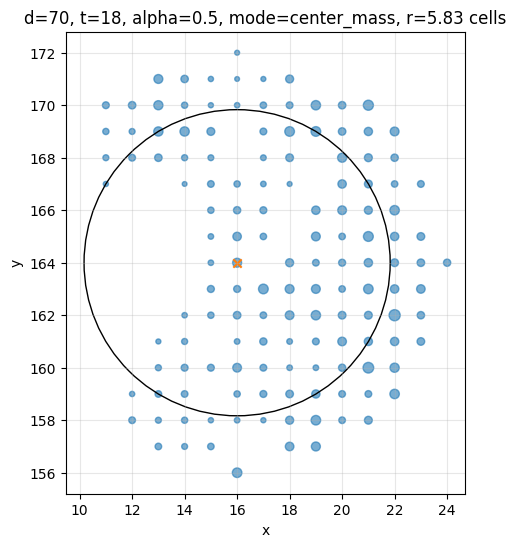

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

def normalize_nonneg(x):
    x = np.asarray(x, dtype=float)
    x = np.clip(x, 0, None)
    s = x.sum()
    return x / s if s > 0 else np.ones_like(x) / len(x)

def plot_one_circle(df_pred, d, t, x0, y0, alpha=0.8, radius_cells=8, mode="centroid"):
    pred_slice = df_pred[(df_pred["d"]==d) & (df_pred["t"]==t)][["x","y","score"]].copy()
    if pred_slice.empty:
        print("No pred data for this (d,t)")
        return

    cells_xy = pred_slice[["x","y"]].to_numpy()
    dist = np.hypot(cells_xy[:,0]-x0, cells_xy[:,1]-y0)
    cand = pred_slice[dist <= radius_cells + 1e-9].copy()
    if len(cand) < 5:
        print("Too few candidate cells")
        return

    cand_xy = cand[["x","y"]].to_numpy()
    p = normalize_nonneg(cand["score"].to_numpy())

    # 先找出「集合」Sα（以 p 由大到小累積）
    order = np.argsort(-p)
    cum = np.cumsum(p[order])
    k = int(np.searchsorted(cum, alpha, side="left")) + 1
    k = min(k, len(order))
    idx_region = order[:k]

    # 由集合生成圈
    if mode == "centroid":
        w = p[idx_region]
        w = w / (w.sum() + 1e-12)
        cx = float(np.sum(cand_xy[idx_region,0] * w))
        cy = float(np.sum(cand_xy[idx_region,1] * w))
        r  = float(np.max(np.hypot(cand_xy[idx_region,0]-cx, cand_xy[idx_region,1]-cy)))
    elif mode == "center_mass":
        # 固定圓心在 query 中心，找最小半徑使圓內累積 p >= alpha
        d2 = np.hypot(cand_xy[:,0]-x0, cand_xy[:,1]-y0)
        o2 = np.argsort(d2)
        cum2 = np.cumsum(p[o2])
        kk = int(np.searchsorted(cum2, alpha, side="left")) + 1
        kk = min(kk, len(o2))
        r = float(d2[o2[kk-1]])
        cx, cy = float(x0), float(y0)
        idx_region = o2[:kk]  # 這裡 region 就是「圓內」點
    else:
        raise ValueError("mode must be 'centroid' or 'center_mass'")

    # 畫圖
    fig, ax = plt.subplots(figsize=(6,6))
    ax.set_aspect("equal", adjustable="box")

    # 用點大小表示機率（不指定顏色）
    sizes = 4000 * p
    ax.scatter(cand_xy[:,0], cand_xy[:,1], s=sizes, alpha=0.6)

    # 標出 query 中心
    ax.scatter([x0], [y0], marker="x")

    # 畫圈
    ax.add_patch(Circle((cx, cy), r, fill=False))

    ax.set_title(f"d={d}, t={t}, alpha={alpha}, mode={mode}, r={r:.2f} cells")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.grid(True, alpha=0.3)
    plt.show()

# 挑一筆 query 看看
q = queries.iloc[10]
d, t, x0, y0 = int(q.d), int(q.t), int(q.x0), int(q.y0)

plot_one_circle(df_pred, d, t, x0, y0, alpha=0.5, radius_cells=8, mode="center_mass")